In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper

custom_basis = {
        'H': [[0, [0.4166123, 1.0]]]
    }
def H2_qubits(bond_length):
    atom_string = f"H 0 0 0; H 0 0 {bond_length}"

    driver = PySCFDriver(
        atom=atom_string,
        basis=custom_basis,
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )

    es_problem = driver.run()
    second_q_op = es_problem.hamiltonian.second_q_op()

    mapper = JordanWignerMapper()
    # mapper = BravyiKitaevMapper()
    # mapper = ParityMapper(num_particles=es_problem.num_particles)
    hamiltonian = mapper.map(second_q_op)
    return hamiltonian.to_list()

bond_lengths = [0.25, 0.45, 0.65, 0.725, 0.80, 1.50, 2.50, 3.00]
data_jw = {}
for r in bond_lengths:
    data_jw[float(r)] = H2_qubits(r)

In [2]:
type(data_jw)

dict

In [3]:
dict_jw = [pauli for pauli, coeff in data_jw[0.25]]
print(dict_jw)

['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']


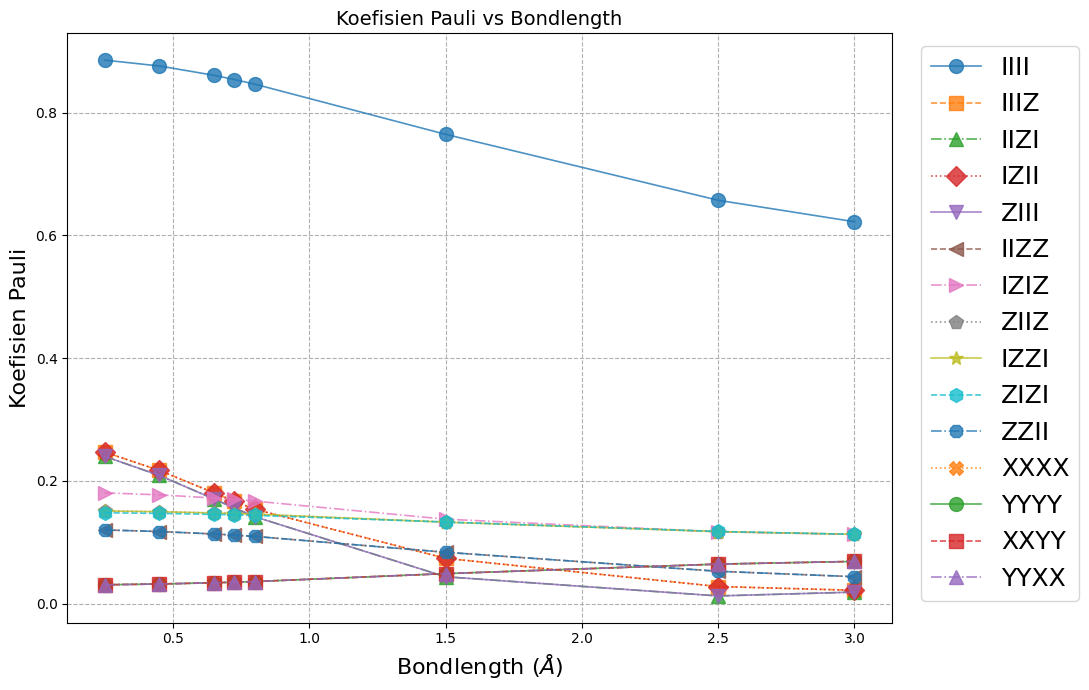

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

# Pilih string yang ingin diplot
opsi_terms = [
    "IIII", "IIIZ", "IIZI", "IZII", "ZIII",
    "IIZZ", "IZIZ", "ZIIZ", "IZZI", "ZIZI", "ZZII",
    "XXXX", "YYYY", "XXYY", "YYXX"
]

bondlengths = np.abs(sorted(data_jw.keys()))

# --- STRATEGI DOUBLE ENCODING ---
# Menyiapkan variasi marker dan gaya garis
markers = itertools.cycle(['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '8', 'X'])
line_styles = itertools.cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(11, 7)) # Sedikit lebih besar untuk menampung banyak informasi

for term in opsi_terms:
    values = []
    for b in bondlengths:
        term_dict = dict(data_jw[b])
        val = term_dict.get(term, 0)
        absolute_value = abs(val.real)
        values.append(absolute_value)
    
    # Tetap biarkan warna otomatis (atau tentukan sendiri)
    # Namun tambahkan marker dan linestyle yang unik untuk tiap term
    plt.plot(bondlengths, values, 
             label=term, 
             marker=next(markers), 
             linestyle=next(line_styles),
             markersize=10, 
             linewidth=1.2,
             alpha=0.8) # Transparansi membantu melihat tumpukan garis

plt.xlabel(r'Bondlength ($\AA$)', fontsize=16)
plt.ylabel('Koefisien Pauli', fontsize=16)
plt.title('Koefisien Pauli vs Bondlength', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=1)

# Membuat legend lebih rapi dengan 2 kolom agar tidak terlalu tinggi
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=18, ncol=1, frameon=True)

plt.tight_layout()
plt.show()

## Analisis Model ML

In [4]:
import os
import pandas as pd
import re
def load_all_tests(type_folder, # Jadikan ini argumen wajib atau opsional
                   base_dir='../hasil_eksperimenV15_jw',
                   rel_path=('ml_training', 'predict_data', 'predicted_data_1.csv')):
    
    # Gabungkan base_dir dengan type_folder
    full_base_path = os.path.join(base_dir, type_folder)
    
    # Fungsi pembantu untuk natural sorting
    def natural_key(text):
        return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

    dataframes = []
    
    # Pastikan folder ada sebelum listdir
    if not os.path.exists(full_base_path):
        raise FileNotFoundError(f"Folder tidak ditemukan: {full_base_path}")

    dir_list = sorted(os.listdir(full_base_path), key=natural_key)

    for test_dir in dir_list:
        csv_path = os.path.join(full_base_path, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir
            dataframes.append(df)
            
    if not dataframes:
        raise FileNotFoundError(f"Tidak ada file di {full_base_path}")

    full_df = pd.concat(dataframes, ignore_index=True)
    
    # Tetap gunakan categorical agar urutan J-S-1, J-S-2 dst tetap terjaga
    full_df['dataset'] = pd.Categorical(full_df['dataset'], categories=dir_list, ordered=True)
    
    return full_df

ALL

In [5]:
rf_table = load_all_tests('all')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table


dataset
J-A-1    0.012208
Name: pred_abs_err, dtype: float64

SINGLE

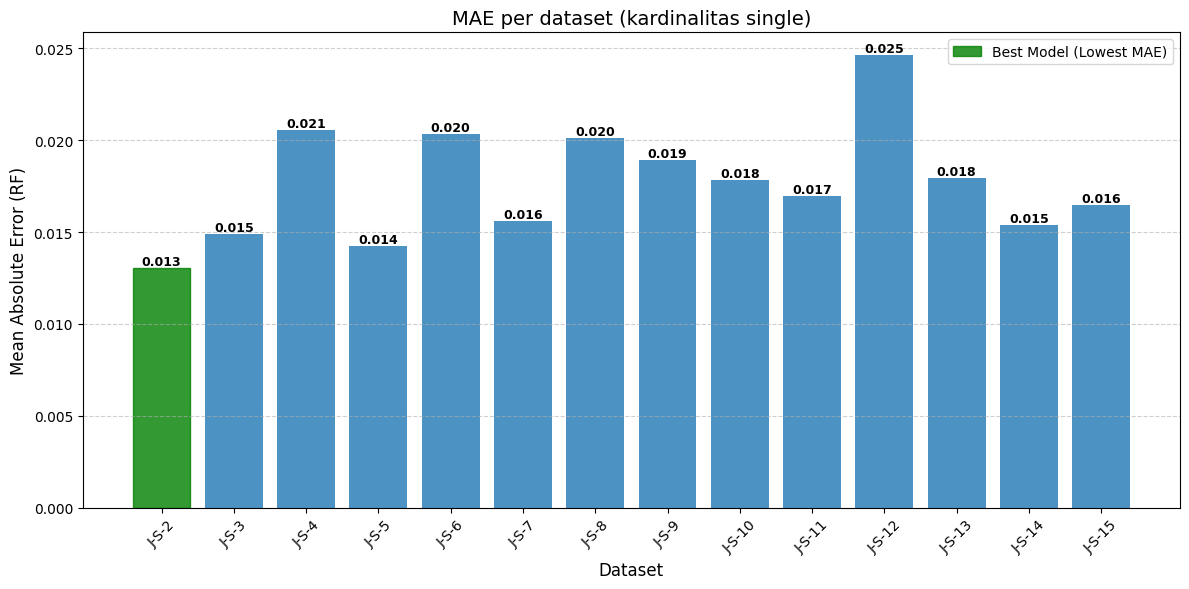

In [6]:
import matplotlib.pyplot as plt

# --- 1. PROSES DATA (Dari kode kedua) ---
df_all = load_all_tests(type_folder='single') 
df_all = df_all[~df_all['dataset'].isin(['J-S-1'])]

# Hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()

# Ubah Series menjadi DataFrame agar sesuai dengan logika 'final_score' di kode referensi
plot_data = rf_means.reset_index()
plot_data.columns = ['dataset', 'mae']

# --- 2. VISUALISASI (Menggunakan metode kode pertama) ---
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_data['dataset'], plot_data['mae'], color='#1f77b4', alpha=0.8)

# Highlight Best Model (Nilai MAE Terendah)
if not plot_data.empty:
    # Cari index dengan nilai MAE terendah
    min_idx = plot_data['mae'].idxmin() 
    
    # Warnai bar tersebut dengan hijau
    bars[min_idx].set_color('green')
    bars[min_idx].set_label('Best Model (Lowest MAE)')

# Menambahkan label nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

# Styling Tambahan
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Mean Absolute Error (RF)", fontsize=12)
plt.title("MAE per dataset (kardinalitas single)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Menampilkan legend (penting untuk label 'Best Model')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

rf_table = load_all_tests('single')

# error absolut dan kuadrat
rf_table["abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table["sq_err"]  = (rf_table["RF_energy"] - rf_table["ideal_energy"])**2

# agregasi per dataset
rf_metrics = rf_table.groupby("dataset", observed=True).agg(
    MAE=("abs_err", "mean"),
    RMSE=("sq_err", lambda x: np.sqrt(x.mean()))
)

rf_metrics.sort_values("MAE")


,MAE,RMSE
dataset,,
J-S-2,0.015014,0.018857
J-S-3,0.016391,0.020939
J-S-5,0.016483,0.021102
J-S-7,0.017144,0.022284
J-S-15,0.017658,0.023444
J-S-4,0.018300,0.025880
J-S-13,0.019332,0.028325
J-S-14,0.019426,0.028364
J-S-11,0.022247,0.034975


DUAL

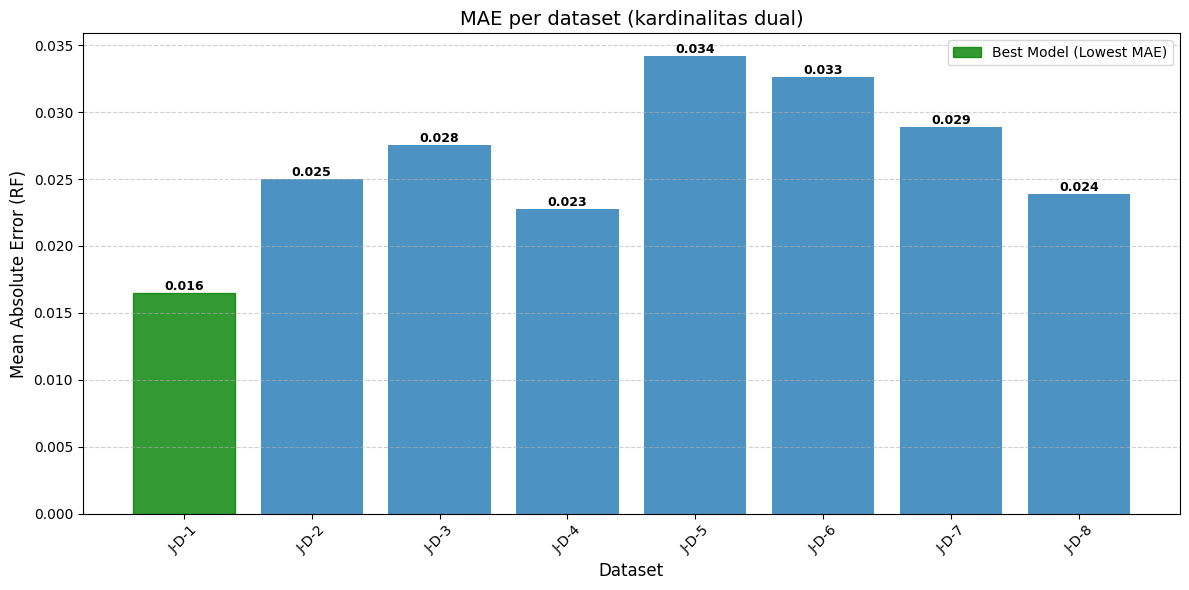

In [8]:
import matplotlib.pyplot as plt

# --- 1. PROSES DATA (Dari kode kedua) ---
df_all = load_all_tests(type_folder='dual') 
df_all = df_all[~df_all['dataset'].isin(['J-S-1'])]

# Hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()

# Ubah Series menjadi DataFrame agar sesuai dengan logika 'final_score' di kode referensi
plot_data = rf_means.reset_index()
plot_data.columns = ['dataset', 'mae']

# --- 2. VISUALISASI (Menggunakan metode kode pertama) ---
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_data['dataset'], plot_data['mae'], color='#1f77b4', alpha=0.8)

# Highlight Best Model (Nilai MAE Terendah)
if not plot_data.empty:
    # Cari index dengan nilai MAE terendah
    min_idx = plot_data['mae'].idxmin() 
    
    # Warnai bar tersebut dengan hijau
    bars[min_idx].set_color('green')
    bars[min_idx].set_label('Best Model (Lowest MAE)')

# Menambahkan label nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

# Styling Tambahan
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Mean Absolute Error (RF)", fontsize=12)
plt.title("MAE per dataset (kardinalitas dual)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Menampilkan legend (penting untuk label 'Best Model')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
rf_table = load_all_tests('dual')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table.sort_values()

dataset
J-D-2    0.020106
J-D-1    0.020972
J-D-5    0.021389
J-D-7    0.022876
J-D-3    0.023865
J-D-4    0.024315
J-D-8    0.024392
J-D-6    0.026549
Name: pred_abs_err, dtype: float64

TRIPLE

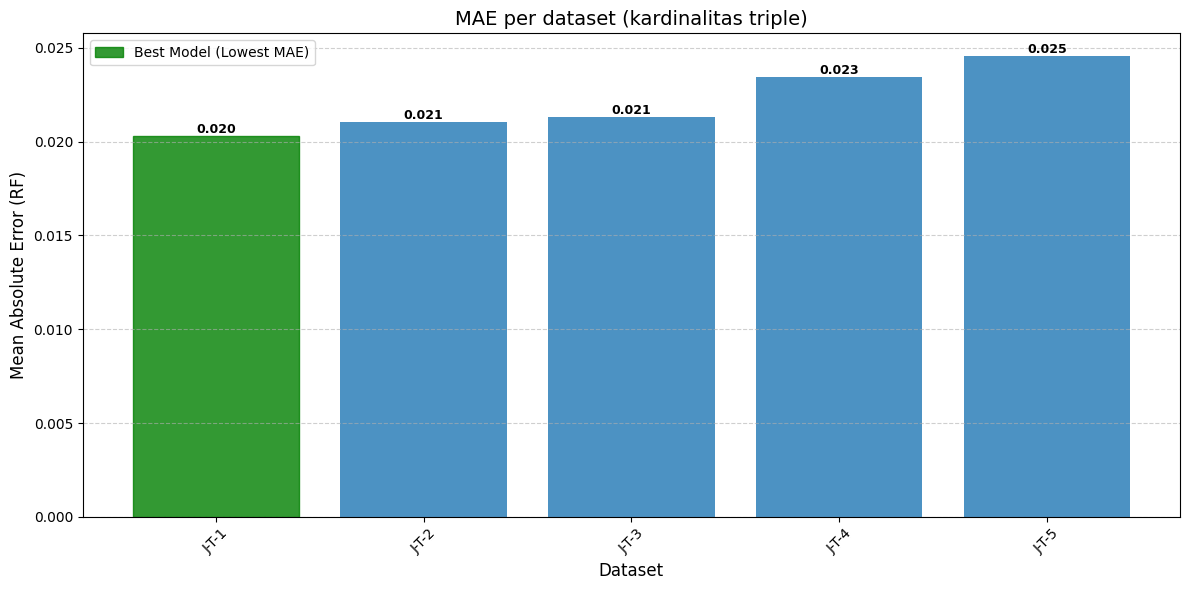

In [7]:
import matplotlib.pyplot as plt

# --- 1. PROSES DATA (Dari kode kedua) ---
df_all = load_all_tests(type_folder='triple') 
df_all = df_all[~df_all['dataset'].isin(['J-S-1'])]

# Hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()

# Ubah Series menjadi DataFrame agar sesuai dengan logika 'final_score' di kode referensi
plot_data = rf_means.reset_index()
plot_data.columns = ['dataset', 'mae']

# --- 2. VISUALISASI (Menggunakan metode kode pertama) ---
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_data['dataset'], plot_data['mae'], color='#1f77b4', alpha=0.8)

# Highlight Best Model (Nilai MAE Terendah)
if not plot_data.empty:
    # Cari index dengan nilai MAE terendah
    min_idx = plot_data['mae'].idxmin() 
    
    # Warnai bar tersebut dengan hijau
    bars[min_idx].set_color('green')
    bars[min_idx].set_label('Best Model (Lowest MAE)')

# Menambahkan label nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

# Styling Tambahan
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Mean Absolute Error (RF)", fontsize=12)
plt.title("MAE per dataset (kardinalitas triple)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Menampilkan legend (penting untuk label 'Best Model')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
rf_table = load_all_tests('triple')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table.sort_values

<bound method Series.sort_values of dataset
J-T-1    0.020319
J-T-2    0.021029
J-T-3    0.021300
J-T-4    0.023426
J-T-5    0.024541
Name: pred_abs_err, dtype: float64>

## data single untuk analisis per observabel

In [6]:
# List observable (pastikan sintaks list benar)
obs = [
    "IIII", "IIIZ", "IIZI", "YYXX", "IZZI",
    "IZII", "ZIII",
    "IIZZ", "IZIZ", 
    "ZIIZ", "ZIZI", "ZZII",
    "XXXX", "YYYY", "XXYY", 
]

In [7]:
import matplotlib.pyplot as plt

def obs_sens(type_filter='single', base_dir='../hasil_eksperimenV12_jw'):
    """
    type_filter: 'single', 'dual', atau 'all' (sesuai nama folder di gambar)
    """
    
    # 1. LOAD DATA
    # Langsung panggil fungsi load yang sudah disesuaikan strukturnya
    try:
        df_all = load_all_tests(type_folder=type_filter, base_dir=base_dir)
    except FileNotFoundError as e:
        print(e)
        return None

    # 2. FILTERING
    # a. Filter Observable
    df_all = df_all[df_all['observable'].isin(obs)]
    
    # b. Filter Dataset Tertentu (Opsional)
    # Jika ingin membuang 'J-S-1' (karena folder 01 biasanya dibuang di kode lama Anda):
    df_all = df_all[~df_all['dataset'].isin(['J-S-1'])]

    if df_all.empty:
        print("Data kosong setelah difilter.")
        return None

    # 3. KALKULASI ERROR
    df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()

    # 4. GROUPING
    # Gunakan observed=True agar kategori 'J-S-1' yang dibuang tidak error/muncul kosong
    rf_means = df_all.groupby(["dataset", "observable"], observed=True)["pred_abs_err"].median().reset_index()

    # 5. PLOTTING
    df_pivot = rf_means.pivot(index='dataset', columns='observable', values='pred_abs_err')
    
    plt.figure(figsize=(12, 6))
    for observable in df_pivot.columns:
        plt.plot(df_pivot.index, df_pivot[observable], marker='o', label=observable, linewidth=2)

    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel("Mean Absolute Error", fontsize=12)
    plt.legend(title="Observable", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # plt.yscale('log')
    plt.xticks(rotation=45) # Putar label x agar J-S-xx tidak bertumpuk
    plt.show()

    return df_pivot

# --- CARA PAKAI ---
# df_hasil = obs_sens(type_filter='single')
# df_hasil_dual = obs_sens(type_filter='dual')

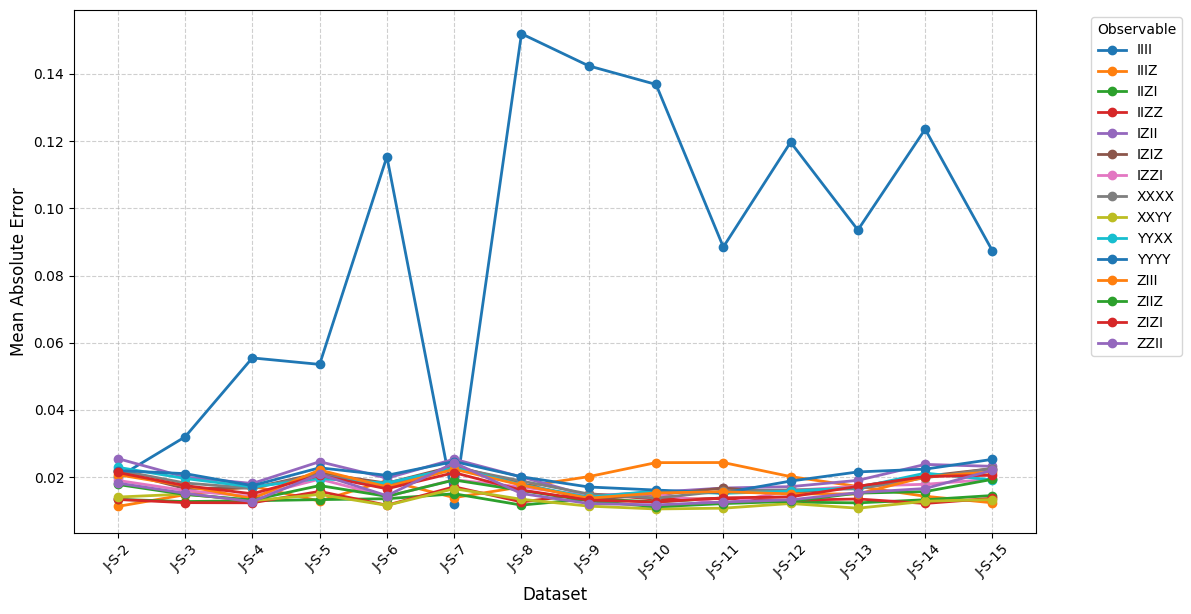

In [12]:
df_pivot_single = obs_sens()

In [39]:
import numpy as np

# Asumsi df_pivot adalah dataframe dari langkah sebelumnya
# baris = kondisi (02, 03...), kolom = observable

metrics = []

for col in df_pivot_single.columns:
    data = df_pivot_single[col]
    
    # 1. Hitung Sensitivitas (Rata-rata lompatan)
    sensitivity = data.diff().abs().mean()
    
    # 2. Hitung Fluktuasi Relatif (CV)
    cv = (data.std() / data.mean()) * 100
    
    # 3. Rentang (Max - Min) untuk melihat volatilitas ekstrem
    data_range = data.max() - data.min()
    
    metrics.append({
        'Observable': col,
        'Sensitivity (Avg Jump)': sensitivity,
        'Fluctuation (CV %)': cv,
        'Total Range': data_range
    })

df_metrics = pd.DataFrame(metrics).sort_values(by='Sensitivity (Avg Jump)', ascending=False)
df_metrics.head()

,Observable,Sensitivity (Avg Jump),Fluctuation (CV %),Total Range
0,IIII,0.0,0.000000e+00,0.0
1,IIIZ,0.0,0.000000e+00,0.0
2,IIZI,0.0,0.000000e+00,0.0
3,IIZZ,0.0,1.742580e-14,0.0
4,IZII,0.0,0.000000e+00,0.0


Run VQE

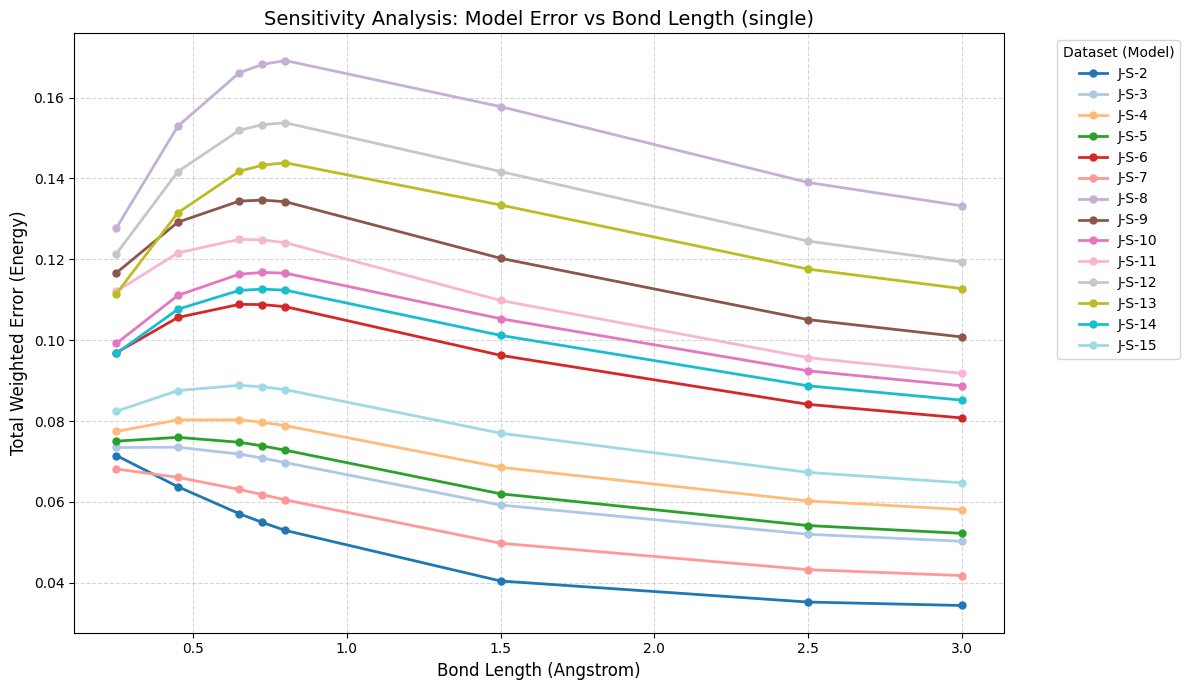

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# --- 1. DATA BOBOT HAMILTONIAN PER BOND LENGTH ---
# Dictionary lengkap sesuai data yang Anda berikan
hamiltonian_data = data_jw

def analyze_bond_sensitivity(type_filter='single', base_dir='../hasil_eksperimenV3_jw'):
    # --- 1. LOAD DATA SEKALI SAJA ---
    try:
        df_all = load_all_tests(type_folder=type_filter, base_dir=base_dir)
    except NameError:
        print("Error: Fungsi 'load_all_tests' belum didefinisikan.")
        return
    
    # --- PREPROCESSING ---
    df_all.columns = df_all.columns.str.strip().str.lower()
    if 'observable' not in df_all.columns:
        df_all = df_all.reset_index()
        df_all.columns = df_all.columns.str.strip().str.lower()
    
    if 'dataset' in df_all.columns:
        df_all = df_all[~df_all['dataset'].isin(['J-S-1'])] # Filter j-s-1
        
    df_all['observable'] = df_all['observable'].astype(str).str.lower()
    
    # Hitung error prediksi (MAE per Pauli string)
    df_all["pred_abs_err"] = (df_all["rf_energy"] - df_all["ideal_energy"]).abs()
    
    # Kelompokkan data: Error rata-rata per Dataset per Observable
    # Ini adalah "Base Error Matrix" kita
    rf_mae_base = df_all.groupby(["dataset", "observable"], observed=True)["pred_abs_err"].mean().reset_index()

    # --- 2. LOOPING PER BOND LENGTH ---
    plot_data = []

    # Sort bond length agar garis di plot nanti urut
    sorted_lengths = sorted(hamiltonian_data.keys())

    for dist in sorted_lengths:
        # Ambil weights untuk jarak ini
        terms = hamiltonian_data[dist]
        
        # Buat dictionary weight {observable: absolute_value}
        current_weights = {k.lower(): abs(v) for k, v in terms}
        
        # Filter observable yang relevan di data kita
        # Hanya hitung jika observable ada di weight dictionary ini
        df_current = rf_mae_base[rf_mae_base['observable'].isin(current_weights.keys())].copy()
        
        if df_current.empty:
            continue
            
        # Terapkan bobot
        df_current['weight_val'] = df_current['observable'].map(lambda x: current_weights.get(x, 0))
        df_current['weighted_error'] = df_current['pred_abs_err'] * df_current['weight_val']
        
        # Sum weighted error per dataset
        dataset_scores = df_current.groupby('dataset', observed=True)['weighted_error'].sum().reset_index()
        
        # Tambahkan info bond length
        dataset_scores['bond_length'] = dist
        
        plot_data.append(dataset_scores)

    # Gabungkan semua hasil
    final_df = pd.concat(plot_data, ignore_index=True)

    # --- 3. PLOTTING ---
    plt.figure(figsize=(12, 7))
    
    # Kita perlu list dataset yang unik dan terurut untuk legend yang rapi
    datasets = sorted(final_df['dataset'].unique(), key=lambda x: [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', str(x))])
    
    # Gunakan colormap agar warna dataset konsisten
    colors = plt.cm.tab20(np.linspace(0, 1, len(datasets)))
    
    for i, ds in enumerate(datasets):
        subset = final_df[final_df['dataset'] == ds]
        plt.plot(subset['bond_length'], subset['weighted_error'], 
                 marker='o', markersize=5, linewidth=2, label=ds, color=colors[i])

    plt.xlabel("Bond Length (Angstrom)", fontsize=12)
    plt.ylabel("Total Weighted Error (Energy)", fontsize=12)
    plt.title(f"Sensitivity Analysis: Model Error vs Bond Length ({type_filter})", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Dataset (Model)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return final_df

# --- JALANKAN ---
df_sensitivity = analyze_bond_sensitivity(type_filter='single')